In [2]:
# I want to do a simultaneous evaluation of the POIs and compute the correlation matrix
import uproot
import os
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import mplhep as hep
import seaborn as sns
import ROOT
import pandas as pd
from scipy import stats
import numpy as np
from scipy.optimize import minimize, curve_fit
from scipy.stats import moment
import json
from itertools import combinations  

In [3]:
# Importing translation dictionary
translationFilePath = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/translation.json"
with open(translationFilePath) as translationFile:
    translation = json.load(translationFile)

In [4]:
# Do everything untrimmed, i.e., include failed fits as -999. Then combine every considered variable into a big json file.
# Should we do a trimming??
def pois_untrimmed(toyDir_, poi_list_):
    pois = {}

    for current_poi in poi_list_:

        pois[current_poi] = []

    for i in range(len(glob.glob(os.path.join(toyDir_, "toy_*")))):

        if i%100==0:
            print(f"Processing fit_{i}")

        try:
            current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombineToyFit.MultiDimFit.mH125.38.root")
            # current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombinefirstStep.MultiDimFit.mH125.root")
        except:
            print(f"Skipping fit_{i}: Required scan files not found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        for j, current_poi in enumerate(poi_list_):

            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                pois[current_poi].append(-999.0)
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if current_limit_values[0]<-4:
                    print("Value out of boundary", current_limit_values[0], i)
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                pois[current_poi].append(-999.0)
                continue

            pois[current_poi].append(float(current_limit_values[0]))
    return pois

In [5]:
def pois_trimmed(toyDir_, poi_list_, trimming_value_left_, trimming_value_right_):
    pois = {}

    for current_poi in poi_list_:

        pois[current_poi] = []

    for i in range(len(glob.glob(os.path.join(toyDir_, "toy_*")))):

        if i%100==0:
            print(f"Processing fit_{i}")

        try:
            current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombineToyFit.MultiDimFit.mH125.38.root")
            # current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombinefirstStep.MultiDimFit.mH125.root")
        except:
            print(f"Skipping fit_{i}: Required scan files not found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        kill_event = False

        # First loop to check if there are outliers (outliers are events smaller than -4 and bigger than 4)
        for j, current_poi in enumerate(poi_list_):
            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                pois[current_poi].append(-999.0)
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if (current_limit_values[0] > trimming_value_right_) or (current_limit_values[0] < trimming_value_left_):
                    kill_event = True 
                    break
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                pois[current_poi].append(-999.0)
                continue

        if kill_event:
            print(f"Skipping fit_{i} with {current_limit_values[0]}: Outlier found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        for j, current_poi in enumerate(poi_list_):

            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if current_limit_values[0]<-4:
                    print("Value out of boundary", current_limit_values[0], i)
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                continue

            pois[current_poi].append(float(current_limit_values[0]))
    return pois

In [6]:
def gaus(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

def create_json_trimmed(variable_, toyDir_, pois_untrimmed_, poi_list_, subfolder_, extra_name=""):

    # Now we have to fit a gaussian core to all the categories to get the values where we cut. z is the number of standard deviations we want to cut away
    trimming_value_left = 0
    trimming_value_right = 0
    largest_sigma = 0
    mu_to_largest_sigma = 0
    z = 4 # 4
    for i, current_poi in enumerate(poi_list_):
        r = np.array(pois_untrimmed_[current_poi])
        r = r[r > -998.0]
        mean = np.mean(r)
        s = np.std(r)
        # r = r[r < 5.0]
        
        bins = 30 # 30
        
        counts, bin_edges = np.histogram(r, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        popt, _ = curve_fit(gaus, bin_centers, counts, p0=[1, mean, s], maxfev=10000)
        amp_fit, mu_fit, sigma_fit = popt
        
        # Define the pull
        pull = (r - 1.0) / s
        mean_pull = np.mean(pull)
        s_pull = np.std(pull)
        skewness_pull = stats.skew(pull)
        kurtosis_pull = stats.kurtosis(pull)

        # Fit for the pulls
        counts_pull, bin_edges_pull = np.histogram(pull, bins=bins, density=False)
        bin_centers_pull = (bin_edges_pull[:-1] + bin_edges_pull[1:]) / 2

        popt_pull, _ = curve_fit(gaus, bin_centers_pull, counts_pull, p0=[1, 0.0, 1], maxfev=10000)
        amp_fit_pull, mu_fit_pull, sigma_fit_pull = popt_pull

        if i == 0:
            largest_sigma = sigma_fit
            mu_to_largest_sigma = mu_fit
        else:
            if (sigma_fit > largest_sigma):
                largest_sigma = sigma_fit
                mu_to_largest_sigma = mu_fit

        if (not os.path.exists(f"./Plots/{variable_}/{subfolder_}")) & (f"./Plots/{variable_}/{subfolder_}"!=""):
            os.makedirs(f"./Plots/{variable_}/{subfolder_}")
        

        plt.figure(figsize=(12, 8))
        plt.style.use(hep.style.CMS)
        hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
        plt.hist(r, bins=bins, density=False, alpha=0.6, label='S+B Toys') #30
        plt.plot(bin_centers, gaus(bin_centers, *popt), color='red', label='Fitted Gaussian')
        plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f} ± {s:.2f}')
        plt.axvline(np.median(r), color='blue', linestyle='--', label=f'Median: {np.median(r):.2f}')
        plt.axvline(1.0, color='grey', linestyle='--', label=r'$\mu=1$')
        plt.legend()
        plt.xlabel(f"{translation[f'{current_poi}']}")
        plt.ylabel(r'$N$')
        plt.savefig(f"./Plots/{variable_}/{subfolder_}/gaussian_fit_{current_poi}.png")
        plt.close()

        # Compute the pull
        plt.figure(figsize=(12, 8))

        # Get axis limits
        xlim = plt.xlim()
        ylim = plt.ylim()

        plt.style.use(hep.style.CMS)
        hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
        plt.hist(pull, bins=bins, density=False, alpha=0.6, label='Pull') #30
        plt.plot(bin_centers_pull, gaus(bin_centers_pull, *popt_pull), color='red', label='Fitted Gaussian')
        plt.text(
            xlim[0] + 0.9*(xlim[1] - xlim[0]),   # 70% across the x-axis
            ylim[0] + 0.8*(ylim[1] - ylim[0]),   # 80% up the y-axis
            f'Mean: {mean_pull:.2f}\nStd Dev: {s_pull:.2f}\nSkewness: {skewness_pull:.2f}\nKurtosis: {kurtosis_pull:.2f}',
            bbox=dict(facecolor='white', alpha=0.5)
        )
        plt.xlabel(f"{translation[f'{current_poi}']}")
        plt.ylabel(r'$N$')
        plt.grid()
        plt.savefig(f"./Plots/{variable_}/{subfolder_}/pull_{current_poi}.png")
        plt.close()

    trimming_value_left = mu_to_largest_sigma - z*largest_sigma
    trimming_value_right = mu_to_largest_sigma + z*largest_sigma

    print("Trimming values: ", trimming_value_left, trimming_value_right)

    if trimming_value_left > trimming_value_right:
        trimming_value_left, trimming_value_right = trimming_value_right, trimming_value_left

    if not os.path.exists(f'pois_trimmed_{variable_}{extra_name}.json'):
        pois = pois_trimmed(toyDir_, poi_list_, trimming_value_left, trimming_value_right)
        # Save the POIs to a JSON file
        with open(f'pois_trimmed_{variable_}{extra_name}.json', 'w') as f:
            json.dump(pois, f)
    else:
        # Load the POIs from the JSON file
        with open(f'pois_trimmed_{variable_}{extra_name}.json', 'r') as f:
            pois = json.load(f)
    
    return pois

In [7]:
def create_json_untrimmed_per_variable(variable_, toyDir_, poi_list_, extra_name=""):
    # Loop through all fit directories (fit_0, fit_1, etc.)
    if not os.path.exists(f'pois_untrimmed_{variable_}{extra_name}.json'):
        pois = pois_untrimmed(toyDir_, poi_list_)
        # Save the POIs to a JSON file
        with open(f'pois_untrimmed_{variable_}{extra_name}.json', 'w') as f:
            json.dump(pois, f)
    else:
        # Load the POIs from the JSON file
        with open(f'pois_untrimmed_{variable_}{extra_name}.json', 'r') as f:
            pois = json.load(f)

    return pois

In [8]:
plot_dir = "Plots"
os.makedirs(plot_dir, exist_ok=True)

In [9]:
# Load PTH toys
variable = "PTH"
# sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_06_12/intermediateRun3/finalfits'
sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_10_14_intermediate/finalfits_postBPix'
main_dir = os.path.join(sample_dir, variable+"_allReplica", "Combine", f"runFits_{variable}")
toyDir = os.path.join(main_dir, "toyFit")

poi_list = ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_30p0_45p0", "r_PTH_45p0_80p0", "r_PTH_80p0_120p0", "r_PTH_120p0_200p0", "r_PTH_200p0_350p0", "r_PTH_350p0_10000p0"]

pois_untrimmed_PTH = create_json_untrimmed_per_variable(variable, toyDir, poi_list)
pois_PTH = create_json_trimmed(variable, toyDir, pois_untrimmed_PTH, poi_list, subfolder_=f"SL_{variable}")

# plot_all_individual_correlation(pois_PTH, poi_list, variable)

Processing fit_0
Value out of boundary -15.999996 0
Value out of boundary -6.51857 16
Value out of boundary -15.999998 20
Value out of boundary -8.76075 25
Value out of boundary -7.0126925 43
Value out of boundary -15.999999 48
Value out of boundary -8.619444 59
Value out of boundary -15.999998 61
Value out of boundary -4.0227466 65
Value out of boundary -16.0 66
Value out of boundary -16.0 70
Value out of boundary -13.789687 73
Processing fit_100
Value out of boundary -7.903728 105
Value out of boundary -16.0 114
Value out of boundary -5.842236 134
Value out of boundary -15.999997 141
Value out of boundary -16.0 144
Value out of boundary -15.999996 159
Value out of boundary -15.999999 190
Value out of boundary -15.999999 194
Processing fit_200
Value out of boundary -16.0 208
Value out of boundary -16.0 212
Value out of boundary -9.295516 228
Value out of boundary -5.8373775 247
Value out of boundary -16.0 250
Value out of boundary -7.10269 252
Value out of boundary -5.27636 256
Value 

In [10]:
# df_PTH = pd.DataFrame(pois_untrimmed_PTH)
# print(df_PTH[(df_PTH['r_PTH_350p0_10000p0'] > -998.0) & (df_PTH['r_PTH_350p0_10000p0'] < -15.8)]['r_PTH_350p0_10000p0'].index.tolist())

In [11]:
# Load NJ toys
variable = "NJ"

main_dir = os.path.join(sample_dir, variable+"_allReplica", "Combine", f"runFits_{variable}")
toyDir = os.path.join(main_dir, "toyFit")

poi_list_NJ = ["r_NJ_0p0_1p0", "r_NJ_1p0_2p0", "r_NJ_2p0_3p0", "r_NJ_3p0_100p0"]

pois_untrimmed_NJ = create_json_untrimmed_per_variable(variable, toyDir, poi_list_NJ)
pois_NJ = create_json_trimmed(variable, toyDir, pois_untrimmed_NJ, poi_list_NJ, subfolder_=f"SL_{variable}")

# plot_all_individual_correlation(pois_untrimmed_NJ, poi_list_NJ, variable)

Processing fit_0
Value out of boundary -4.04901 3
Value out of boundary -4.4991727 11
Value out of boundary -4.2731643 12
Value out of boundary -5.916867 19
Value out of boundary -4.9760776 25
Value out of boundary -6.2288795 26
Value out of boundary -4.635956 29
Value out of boundary -4.303458 32
Value out of boundary -6.4079556 35
Value out of boundary -5.6054792 39
Value out of boundary -7.882781 42
Value out of boundary -9.999996 46
Value out of boundary -5.8555717 51
Value out of boundary -8.332848 54
Value out of boundary -4.350549 57
Value out of boundary -7.288807 58
Value out of boundary -5.2801633 59
Value out of boundary -7.5259414 61
Value out of boundary -6.2477956 62
Value out of boundary -6.368955 63
Value out of boundary -4.5095935 64
Value out of boundary -6.947071 68
Value out of boundary -5.472691 78
Value out of boundary -4.922756 79
Value out of boundary -4.7246237 85
Value out of boundary -6.50259 90
Value out of boundary -4.42861 91
Value out of boundary -4.30906

In [12]:
df_PTH = pd.DataFrame(pois_PTH)
df_NJ = pd.DataFrame(pois_NJ)
# df_PTJ0 = pd.DataFrame(pois_PTJ0)
# df_rapidity = pd.DataFrame(pois_rapidity)


In [13]:
df_PTH_untrimmed = pd.DataFrame(pois_untrimmed_PTH)
df_NJ_untrimmed = pd.DataFrame(pois_untrimmed_NJ)
mask_pth_untrimmed = (df_PTH_untrimmed != -999).all(axis=1)
mask_nj_untrimmed = (df_NJ_untrimmed != -999).all(axis=1)
valid_rows_untrimmed = mask_pth_untrimmed & mask_nj_untrimmed
df_PTH_clean_untrimmed = df_PTH_untrimmed[valid_rows_untrimmed]
df_NJ_clean_untrimmed = df_NJ_untrimmed[valid_rows_untrimmed]

In [14]:

# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# # Mask for df_PTH (True = valid, False = -999)
mask_pth = (df_PTH != -999).all(axis=1)

# # Mask for df_NJ (True = valid, False = -999)
mask_nj = (df_NJ != -999).all(axis=1)

# # Mask for df_PTJ0 (True = valid, False = -999)
# mask_ptj0 = (df_PTJ0 != -999).all(axis=1)

# # Mask for df_DPhiJ0J1 (True = valid, False = -999)
# mask_DPhiJ0J1 = (df_DPhiJ0J1 != -999).all(axis=1)

# # Mask for df_rapidity (True = valid, False = -999)
# mask_rapidity = (df_rapidity != -999).all(axis=1)

# Combined mask (keep only rows valid in BOTH DataFrames)
# valid_rows = mask_pth & mask_nj & mask_ptj0 & mask_DPhiJ0J1 & mask_rapidity
valid_rows = mask_pth & mask_nj

# --- Step 2: Filter DataFrames ---
df_PTH_clean = df_PTH[valid_rows]
df_NJ_clean = df_NJ[valid_rows]
# df_PTJ0_clean = df_PTJ0[valid_rows]
# df_DPhiJ0J1_clean = df_DPhiJ0J1[valid_rows]
# df_rapidity_clean = df_rapidity[valid_rows]

# --- Step 3: Compute Correlation Matrix ---
# Combine columns (now aligned and cleaned)
# df_combined = pd.concat([df_PTH_clean, df_DPhiJ0J1_clean, df_NJ_clean, df_PTJ0_clean, df_rapidity_clean], axis=1)
df_combined = pd.concat([df_PTH_clean, df_NJ_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_PTJ0_clean, df_NJ_clean], axis=1)

# Calculate full correlation matrix
corr_matrix = df_combined.corr()

# # Extract cross-correlations (PTH vs. NJ bins)
# pth_cols = df_PTH.columns
# nj_cols = df_NJ.columns
# ptj0_cols = df_PTJ0.columns
# print(ptj0_cols)
# cross_corr = corr_matrix.loc[pth_cols, nj_cols, ptj0_cols]

# print("Correlation Matrix (Excluding Rows with -999):")
# print(cross_corr)

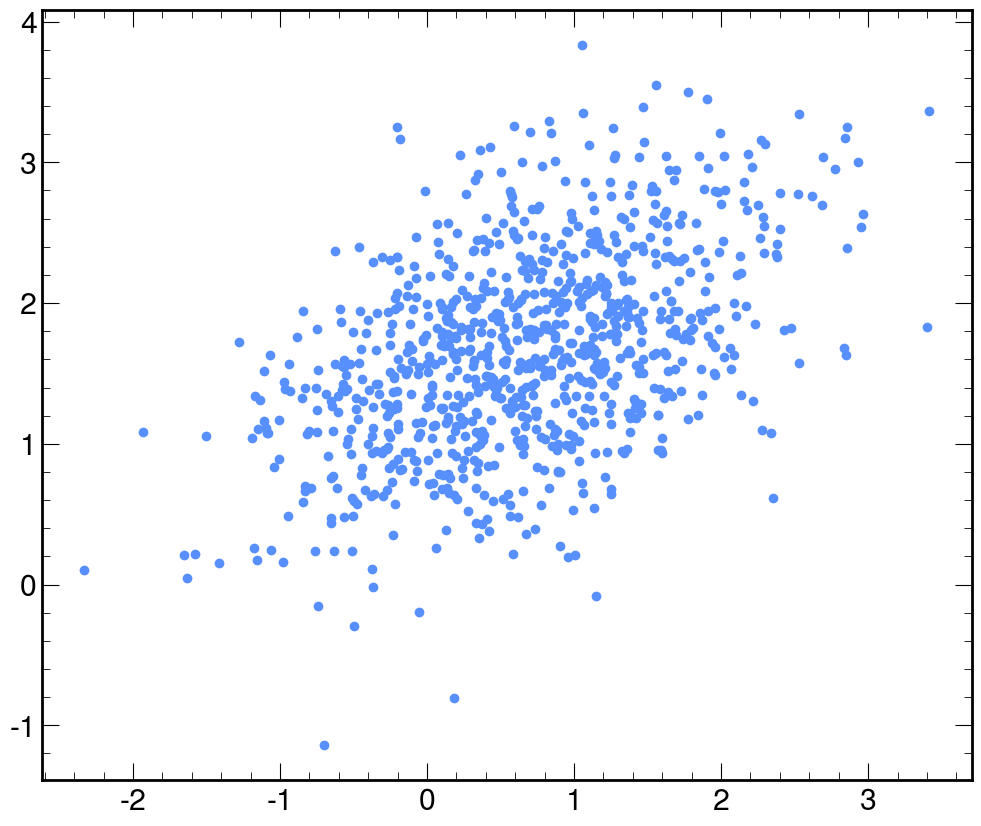

0.4715619032444432


In [15]:
plt.figure(figsize=(12, 10))
plt.scatter(df_PTH_clean["r_PTH_0p0_15p0"], df_NJ_clean["r_NJ_0p0_1p0"])
plt.show()
print(df_PTH_clean["r_PTH_0p0_15p0"].corr(df_NJ_clean["r_NJ_0p0_1p0"]))


In [16]:
# 1️⃣ Define your stops and RGB values
stops = [0.0, 0.5, 1.0]
red   = [0.992, 1.0, 0.110]
green = [0.749, 1.0, 0.196]
blue  = [0.106, 1.0, 0.867]

# 2️⃣ Build the color dictionary
cdict = {
    'red':   [(stops[i], red[i], red[i]) for i in range(len(stops))],
    'green': [(stops[i], green[i], green[i]) for i in range(len(stops))],
    'blue':  [(stops[i], blue[i], blue[i]) for i in range(len(stops))]
}

# 3️⃣ Create the colormap
custom_cmap = LinearSegmentedColormap('gradient_8289', cdict)

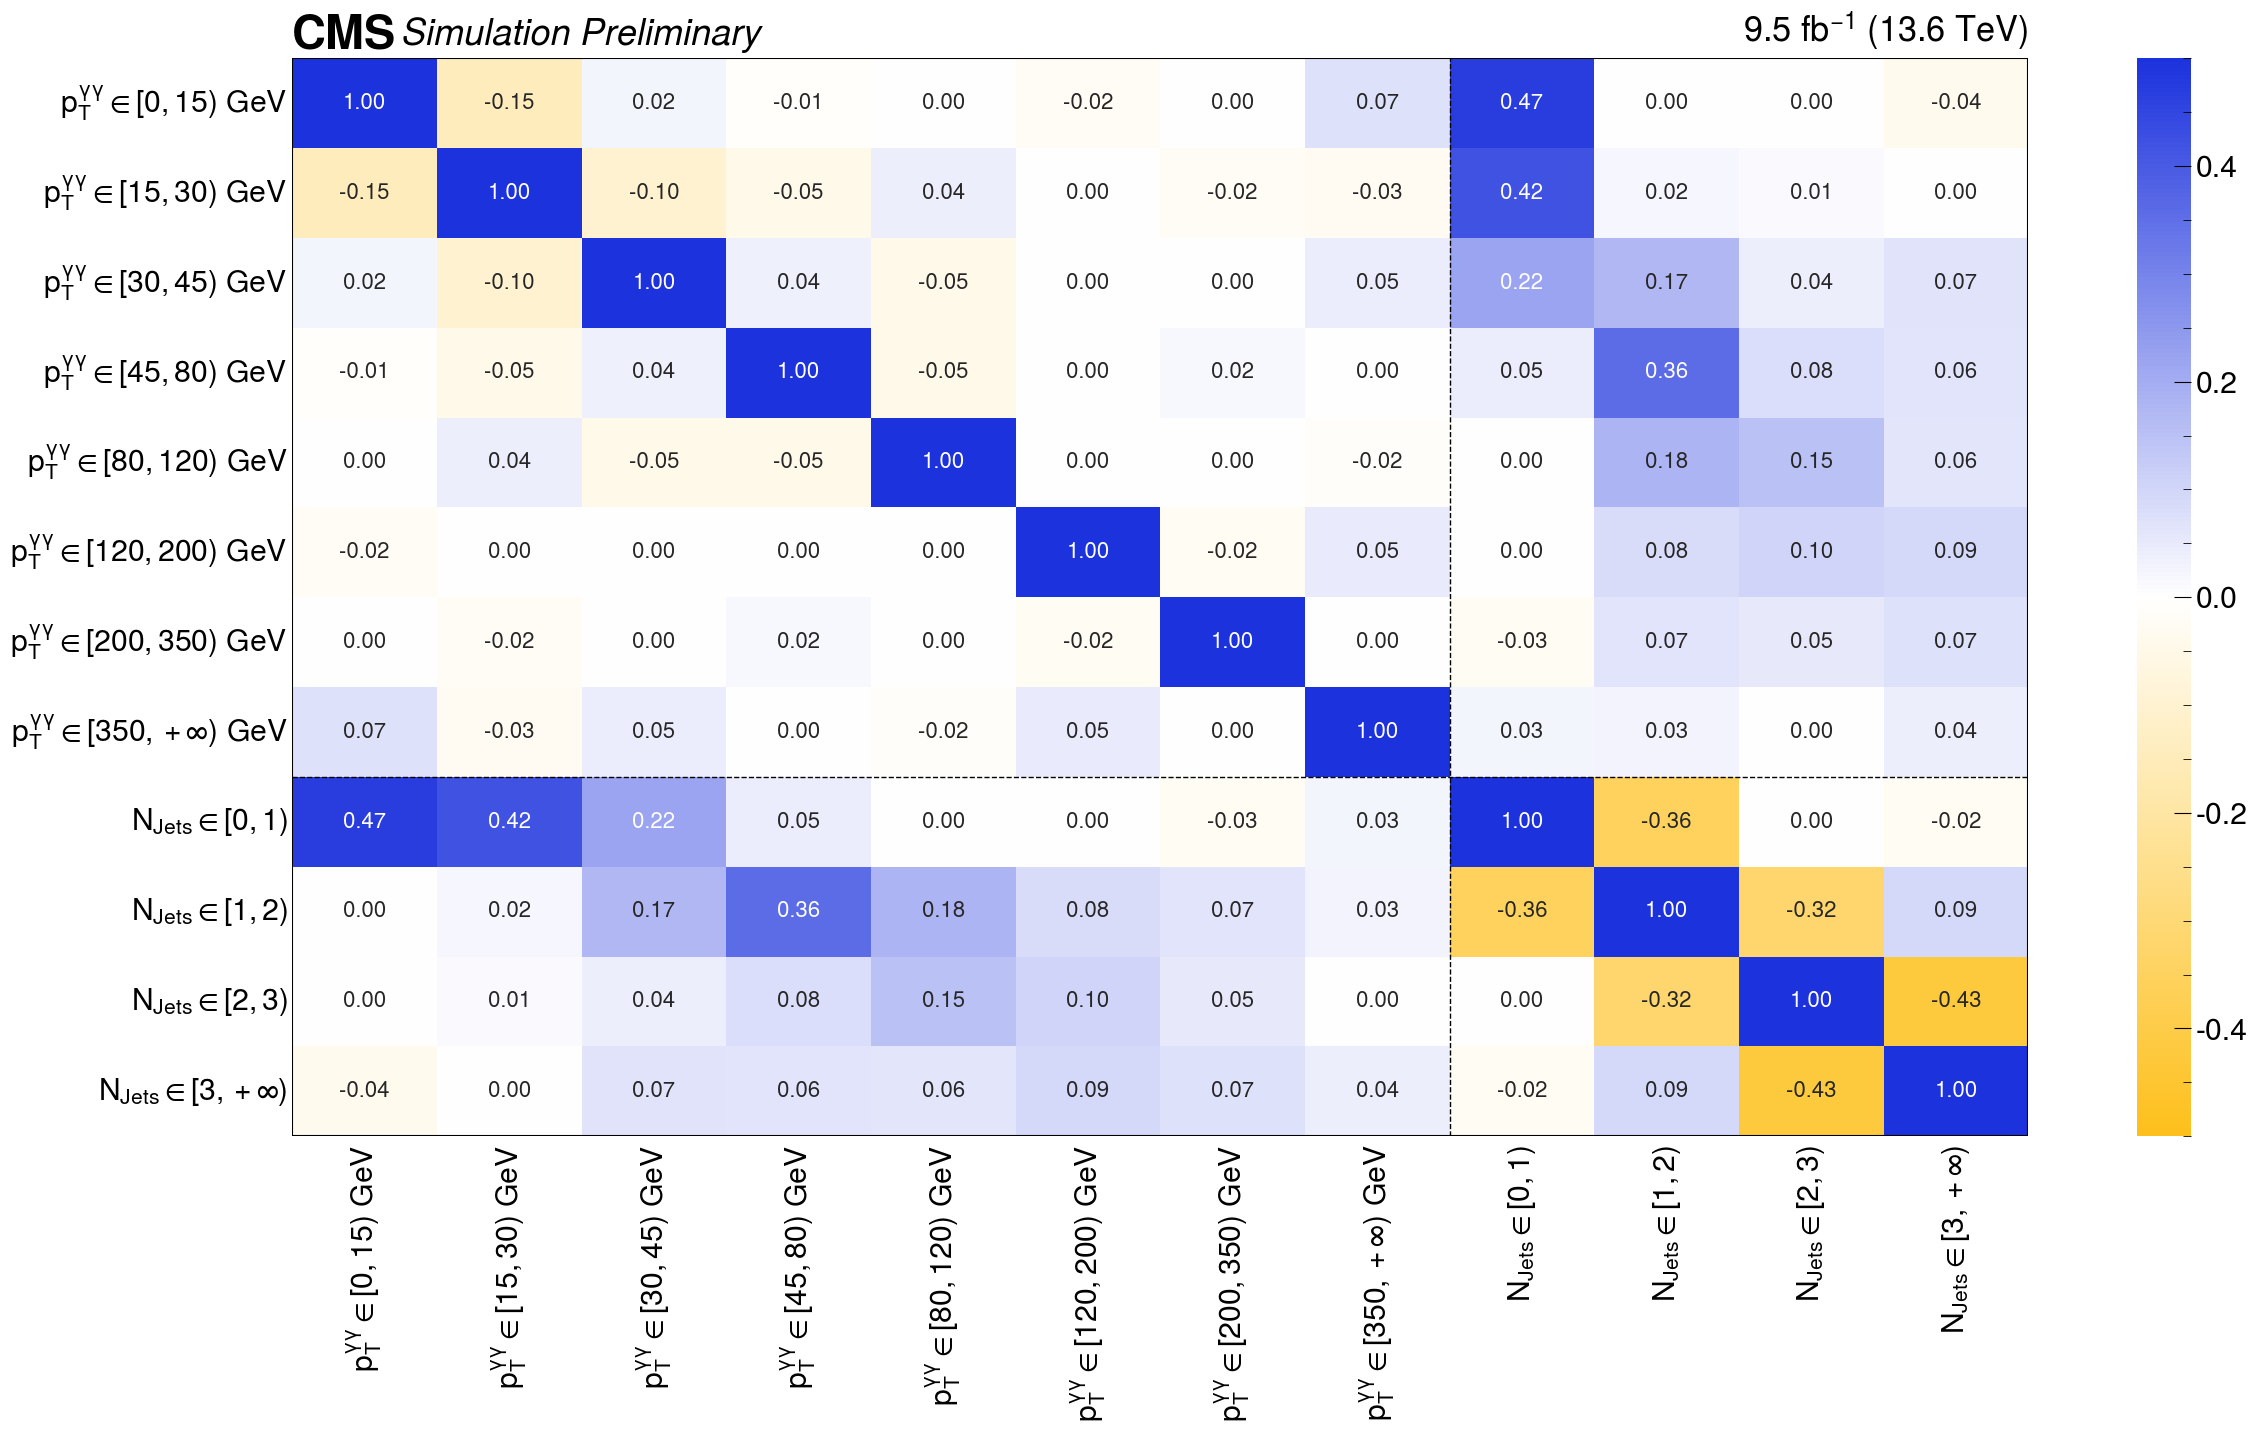

In [17]:
modified_corr_matrix = corr_matrix.copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(28, 14))
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
ax = sns.heatmap(modified_corr_matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [8, 12, 17, 23]  # Example indices between variable blocks # 8, 14, 18, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join(plot_dir, "correlation_matrix.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(plot_dir, "correlation_matrix.png"), bbox_inches='tight')

# plt.close()


In [18]:
def plot_matrix(matrix, boundary, filename):
    plt.figure(figsize=(14, 8))
    plt.style.use(hep.style.CMS)
    hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
    ax = sns.heatmap(matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

    ax.tick_params(
        axis='both',      # apply to both axes
        which='both',     # apply to both major and minor ticks
        bottom=False,     # remove bottom ticks
        top=False,        # remove top ticks
        left=False,       # remove left ticks
        right=False,      # remove right ticks
        labelbottom=True, # keep labels if you want
        labelleft=True    # keep labels if you want
    )

    # Get the number of rows and columns
    n_rows, n_cols = matrix.shape

    # Add rectangle around the whole heatmap to complete the outer box
    rect = Rectangle(
        (0, 0),          # bottom left corner
        width=n_cols,    # number of columns
        height=n_rows,   # number of rows
        fill=False,      # no fill, just the edge
        edgecolor='black',
        linewidth=1.5
    )
    ax.add_patch(rect)

    # Draw thick lines between groups
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

    plt.savefig(os.path.join(plot_dir, f"{filename}.pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(plot_dir, f"{filename}.png"), bbox_inches='tight')


In [ ]:
# df_combined = pd.concat([df_PTH_clean, df_DPhiJ0J1_clean, df_NJ_clean, df_PTJ0_clean, df_rapidity_clean], axis=1)

df_combined_dict = {
    "PTH": df_PTH_clean,
    "DPhiJ0J1": df_DPhiJ0J1_clean,
    "NJ": df_NJ_clean,
    "PTJ0": df_PTJ0_clean,
    "rapidity": df_rapidity_clean
}

variable_names = ["PTH", "DPhiJ0J1", "NJ", "PTJ0", "rapidity"]
variable_pairs = list(combinations(variable_names, 2))

# Define group boundaries (between variable blocks)
group_boundaries = {
    "PTH": 8,
    "DPhiJ0J1": 6,
    "NJ": 4,
    "PTJ0": 5,
    "rapidity": 5
}

for i, (variable1, variable2) in enumerate(variable_pairs):
    df_combined_reduced = pd.concat([df_combined_dict[variable1], df_combined_dict[variable2]], axis=1)
    matrix = df_combined_reduced.corr()
    modified_matrix = matrix.copy()
    modified_matrix = modified_matrix.where(abs(modified_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0
    modified_matrix = modified_matrix.rename(index=translation, columns=translation)
    boundary = group_boundaries[variable1]
    filename = f"correlation_matrix_{variable1}vs{variable2}"
    plot_matrix(modified_matrix, boundary, filename)


In [ ]:
z_hat = 0.5 * np.log((1 + corr_matrix) / (1 - corr_matrix)) + (corr_matrix / (2*(len(df_combined) - 2)))
a = np.tanh(z_hat - np.sqrt(1 / (len(df_combined) - 3)))
b = np.tanh(z_hat + np.sqrt(1 / (len(df_combined) - 3)))

In [ ]:
b - corr_matrix

In [ ]:
corr_matrix - a

In [ ]:
# From Wikipedia https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
np.sqrt((1 - corr_matrix**2) / (len(df_combined) - 2))

In [ ]:
# Load combine toys
combineToy_dir = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/CombineToy_Validation/toys"
variable = "PTH"

pois_untrimmed_combineToys = create_json_untrimmed(variable, combineToy_dir, poi_list, extra_name="_combineToys")
pois_combineToys = create_json_trimmed(variable, combineToy_dir, pois_untrimmed_combineToys, poi_list, subfolder_=f"SL_{variable}", extra_name="_combineToys")

In [ ]:
df_combine = pd.DataFrame(pois_untrimmed_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_combine = df_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_combine = df_combine.corr()

In [ ]:
corr_matrix_combine
sns.heatmap(corr_matrix_combine, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1)

In [ ]:
# z = 5

In [ ]:
# z = 1

In [ ]:
# z = 2

In [ ]:
# z = 4


In [ ]:
np.corrcoef(df_combine["r_PTH_15p0_30p0"], df_combine["r_PTH_350p0_10000p0"])[0,1]

In [ ]:
df_combine = pd.DataFrame(pois_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_combine = df_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_combine = df_combine.corr()
np.corrcoef(df_combine["r_PTH_15p0_30p0"], df_combine["r_PTH_350p0_10000p0"])[0,1]

In [ ]:
plot_all_individual_correlation(pois_untrimmed_combineToys, poi_list, variable)

In [ ]:
df_untrimmed_combine = pd.DataFrame(pois_untrimmed_combineToys)
# --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
mask_combine = (df_untrimmed_combine != -999).all(axis=1)

# --- Step 2: Filter DataFrames ---
df_untrimmed_combine = df_untrimmed_combine[mask_combine]

# Calculate full correlation matrix
corr_matrix_untrimmed_combine = df_untrimmed_combine.corr()

In [ ]:
plt.figure(figsize=(18, 8))
sns.heatmap(corr_matrix_untrimmed_combine, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1)

In [ ]:
df_untrimmed_NJ = pd.DataFrame(pois_untrimmed_NJ)
df_untrimmed_PTJ0 = pd.DataFrame(pois_untrimmed_PTJ0)

In [ ]:
df_untrimmed_NJ

In [ ]:
df_untrimmed_PTJ0